In [1]:
from minisom import MiniSom
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
dataset = fetch_openml(data_id=3, as_frame=True, parser='auto')

In [3]:
X = pd.concat([dataset.data, dataset.target], axis=1)

In [4]:
type(X)

pandas.DataFrame

In [5]:
X.head()

,bkblk,bknwy,bkon8,bkona,bkspr,bkxbq,bkxcr,bkxwp,blxwp,bxqsq,...,spcop,stlmt,thrsk,wkcti,wkna8,wknck,wkovl,wkpos,wtoeg,class
0,f,f,f,f,f,f,f,f,f,f,...,f,f,f,f,f,f,t,t,n,won
1,f,f,f,f,t,f,f,f,f,f,...,f,f,f,f,f,f,t,t,n,won
2,f,f,f,f,t,f,t,f,f,f,...,f,f,f,f,f,f,t,t,n,won
3,f,f,f,f,f,f,f,f,t,f,...,f,f,f,f,f,f,t,t,n,won
4,f,f,f,f,f,f,f,f,f,f,...,f,f,f,f,f,f,t,t,n,won


In [6]:
colunas_f_t = []

In [7]:
for col in X.columns:
    if X[col].nunique() < 3 and set(X[col].unique()) <= {'f', 't'}:
        colunas_f_t.append(col)

In [8]:
for col in ['dwipd', 'katri', 'wtoeg']:
    print(f'{col}: {sorted(X[col].unique())}')

dwipd: ['g', 'l']
katri: ['b', 'n', 'w']
wtoeg: ['n', 't']


In [9]:
## OneHotEncoder (OHE) do scikit: 
# sparse_output=False retorna uma matriz com os 0s bem definidos, se fosse True, retornaria um array do Numpy
# handle_unknown='ignore' evita que o encoding falhe caso o conjunto de treino não tenha todos os dados do conjunto de teste
# set_output(transform='pandas') garante que o output do transform será um DF e não uma série
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform="pandas") 

In [30]:
X[colunas_f_t] = X[colunas_f_t].astype("str").replace({'f': 0, 't': 1})
X[["dwipd", "wtoeg"]] = X[["dwipd", "wtoeg"]].astype("str").replace({
    'f': 0, 't': 1,
    'n': 0, 
    'g': 1, 'l': 0
})
X["class"] = X["class"].astype("str").replace({'won': 1, 'nowin':0})

In [31]:
ohe.fit(X[["katri"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [32]:
X.shape

(3196, 37)

In [33]:
X_ohe = ohe.transform(X[["katri"]])

In [34]:
X.drop(columns="katri")

,bkblk,bknwy,bkon8,bkona,bkspr,bkxbq,bkxcr,bkxwp,blxwp,bxqsq,...,spcop,stlmt,thrsk,wkcti,wkna8,wknck,wkovl,wkpos,wtoeg,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,1
2,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,1,1,0,1
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,1,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3191,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,1,0,1,0,0,0
3192,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,1,0,1,0,0,0
3193,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,1,0,1,0,0,0
3194,1,0,1,0,0,0,1,0,0,0,...,0,1,0,0,1,0,0,0,0,0


In [35]:
X_after_ohe = pd.concat([X, X_ohe], axis=1)

In [36]:
X_after_ohe.shape

(3196, 40)

In [37]:
X_after_ohe.dtypes

bkblk           str
bknwy           str
bkon8           str
bkona           str
bkspr           str
bkxbq           str
bkxcr           str
bkxwp           str
blxwp           str
bxqsq           str
cntxt           str
dsopp           str
dwipd           str
hdchk           str
katri      category
mulch           str
qxmsq           str
r2ar8           str
reskd           str
reskr           str
rimmx           str
rkxwp           str
rxmsq           str
simpl           str
skach           str
skewr           str
skrxp           str
spcop           str
stlmt           str
thrsk           str
wkcti           str
wkna8           str
wknck           str
wkovl           str
wkpos           str
wtoeg           str
class        object
katri_b     float64
katri_n     float64
katri_w     float64
dtype: object

In [38]:
X_after_ohe.drop("katri", axis=1, inplace=True)

In [39]:
X_after_ohe = X_after_ohe.astype(float).to_numpy()

In [42]:
som = MiniSom(40, 40, 39, sigma=25, learning_rate=0.1)

In [43]:
som.train_batch(X_after_ohe, num_iteration=2000000)

In [44]:
som.quantization_error(X_after_ohe)

np.float64(1.900631502747682)

In [45]:
som.topographic_error(X_after_ohe)

np.float64(0.008760951188986232)

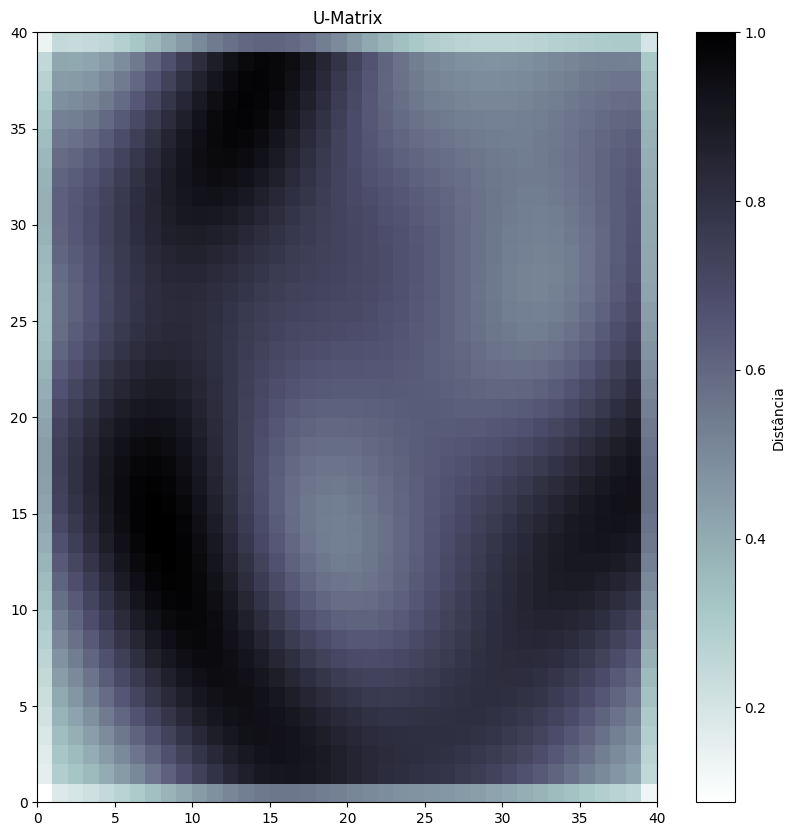

In [46]:
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distância')
plt.title('U-Matrix')
plt.show()


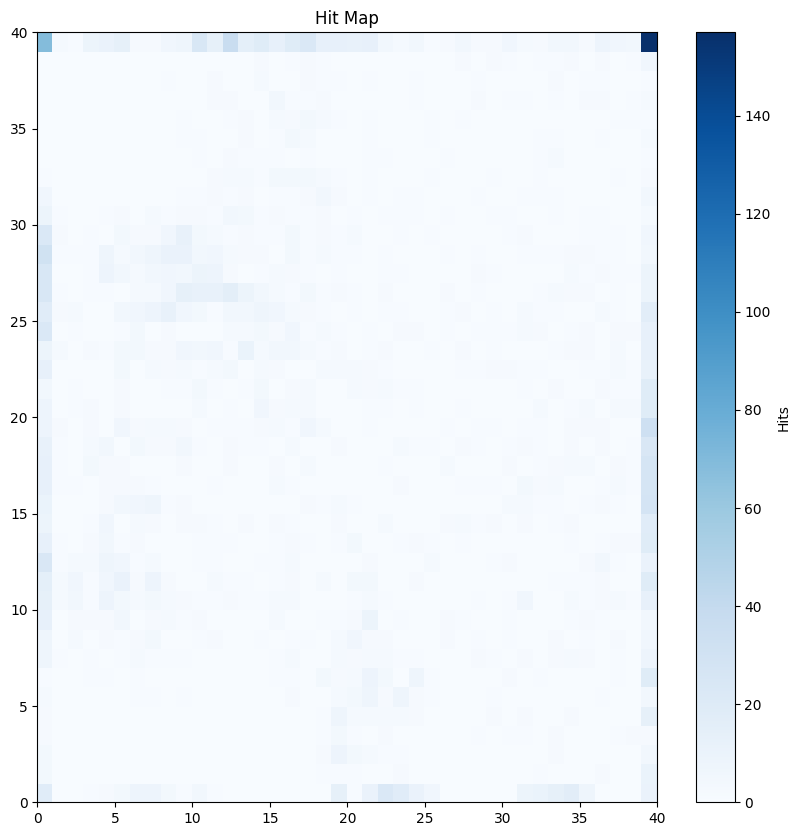

In [47]:
plt.figure(figsize=(10, 10))
plt.pcolor(som.activation_response(X_after_ohe).T, cmap='Blues')
plt.colorbar(label='Hits')
plt.title('Hit Map')
plt.show()
